# P1 · Embeddings and positions

Unit 0 foundations for the current Tiny Transformer and the later Phyll course. Basic Python variables, loops and functions are assumed.

Download and open this notebook in Jupyter, or choose **File → Upload notebook** in Google Colab. All examples and the required helper code are included. No account key, private repository, GPU or dataset download is needed.

Examples are **illustrative**, executed with Python and PyTorch. Newly constructed model weights are explicitly untrained. Run from a fresh kernel in order. Each exercise can run before you fill it in; open its folded solution afterward.

The `show` helper prints named intermediate results. It is course code, not a built-in Python or PyTorch function.

In [1]:
import sys, math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
torch.set_num_threads(1)
torch.manual_seed(7)
print("Python", sys.version.split()[0], "· PyTorch", torch.__version__, "· CPU")
print("Reference environment: Python 3.12 / PyTorch 2.10. Run with Colab's installed PyTorch or the course requirements.txt.")


Python 3.12.3 · PyTorch 2.10.0+cpu · CPU
Reference environment: Python 3.12 / PyTorch 2.10. Run with Colab's installed PyTorch or the course requirements.txt.


Publication destination: the [public course labs repository](https://github.com/gkiri/tiny_repo). This notebook includes its own examples and can run before that mirror is published.

In [2]:
#@title Display helper: print and draw executed values { display-mode: "form" }
"""Small display helper embedded verbatim in independent notebooks; traces record real executions."""
import json
import math

FRAMES = []


def plain(value):
    if hasattr(value, "detach"):
        return plain(value.detach().cpu().tolist())
    if isinstance(value, dict):
        return {str(k): plain(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [plain(v) for v in value]
    if isinstance(value, float) and not math.isfinite(value):
        return str(value)
    if value is None or isinstance(value, (str, int, float, bool)):
        return value
    return str(value)


def show(label, value):
    """Print and snapshot an intermediate. This helper is course code, not a PyTorch API."""
    frame = {"label": label, "value": plain(value)}
    if hasattr(value, "shape"):
        frame.update(shape=list(value.shape), dtype=str(value.dtype), device=str(value.device))
    FRAMES.append(frame)
    print(label + ":", json.dumps(frame["value"], ensure_ascii=False))
    if "shape" in frame:
        print("  shape", frame["shape"], "·", frame["dtype"], "·", frame["device"])


def draw_trace():
    """A portable SVG trace diagram; requires only the notebook's existing IPython display."""
    import html
    from IPython.display import SVG, display
    height = 82 * len(FRAMES) + 12
    parts = [f'<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 720 {height}" role="img" aria-label="Executed intermediate values">']
    for i, frame in enumerate(FRAMES):
        y = 8 + 82*i
        value = json.dumps(frame["value"], ensure_ascii=False)
        if len(value) > 91:
            value = value[:88] + "…"
        parts += [f'<rect x="4" y="{y}" width="708" height="68" rx="10" fill="#f4f8ef" stroke="#779861"/>',
                  f'<text x="20" y="{y+25}" font-size="15" font-family="sans-serif" fill="#31524b">{i+1}. {html.escape(frame["label"])}</text>',
                  f'<text x="20" y="{y+48}" font-size="12" font-family="monospace" fill="#252a33">{html.escape(value)}</text>']
        if i + 1 < len(FRAMES):
            parts.append(f'<path d="M360 {y+68} v14" stroke="#7042a6" stroke-width="2"/>')
    display(SVG("".join(parts) + "</svg>"))

## P1.9 · Embeddings and positions

An embedding selects a learned vector by ID. A learned position lookup adds information about the token’s slot.

**Prerequisites:** Matrix multiplication and linear layers

**Predict:** Does repeating an ID select the same token vector before position addition?

**Mental model:** An ID is a discrete label. An embedding table supplies the floating-point vector that the transformer uses to represent that label.

### Why this operation exists

An ID is a discrete label. An embedding table supplies the floating-point vector that the transformer uses to represent that label.

Lookup selects one learned vector for each input ID. The input's axes are preserved and a feature axis is appended.

Repeating an ID selects the same token vector before context-dependent processing. Appearing in a different position does not by itself change that lookup.

A separate position table selects a vector for the slot. Adding it gives the model's later operations access to both token identity and position information.

The values in this example are set by hand for inspection. In the actual model, training learns the table entries.

### Follow the values

The input contains one sequence of three IDs: one, one and three. Repeating one makes the repeated lookup visible.

The token table contains four vectors of three features. ID one selects the vector three, four and five.

The first two token vectors are equal, while ID three selects nine, ten and eleven. The result has batch, time and feature axes.

Position zero adds zeros in this illustration. Position one adds one tenth, two tenths and three tenths; position two has its own vector.

The equal token vectors now produce different sums because their slots differ. Change the second token ID and observe token identity changing independently from its slot.

In [3]:
FRAMES.clear()
change = 0
torch.manual_seed(7)
table = nn.Embedding(4, 3)
positions = nn.Embedding(3, 3)
with torch.no_grad():
    table.weight.copy_(torch.arange(12).reshape(4,3).float())
    positions.weight.copy_(torch.tensor([[0.,0.,0.],[.1,.2,.3],[.4,.5,.6]]))
ids = torch.tensor([[1, 2 if change else 1, 3]])
show("Input IDs [1,3]", ids)
show("Illustrative lookup table [4,3]", table.weight)
tokens = table(ids)
show("Selected token vectors [1,3,3]", tokens)
pos = positions(torch.arange(ids.size(1)))
show("Position vectors [3,3]", pos)
show("Token plus position", tokens + pos)

Input IDs [1,3]: [[1, 1, 3]]
  shape [1, 3] · torch.int64 · cpu
Illustrative lookup table [4,3]: [[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0], [9.0, 10.0, 11.0]]
  shape [4, 3] · torch.float32 · cpu
Selected token vectors [1,3,3]: [[[3.0, 4.0, 5.0], [3.0, 4.0, 5.0], [9.0, 10.0, 11.0]]]
  shape [1, 3, 3] · torch.float32 · cpu
Position vectors [3,3]: [[0.0, 0.0, 0.0], [0.10000000149011612, 0.20000000298023224, 0.30000001192092896], [0.4000000059604645, 0.5, 0.6000000238418579]]
  shape [3, 3] · torch.float32 · cpu
Token plus position: [[[3.0, 4.0, 5.0], [3.0999999046325684, 4.199999809265137, 5.300000190734863], [9.399999618530273, 10.5, 11.600000381469727]]]
  shape [1, 3, 3] · torch.float32 · cpu


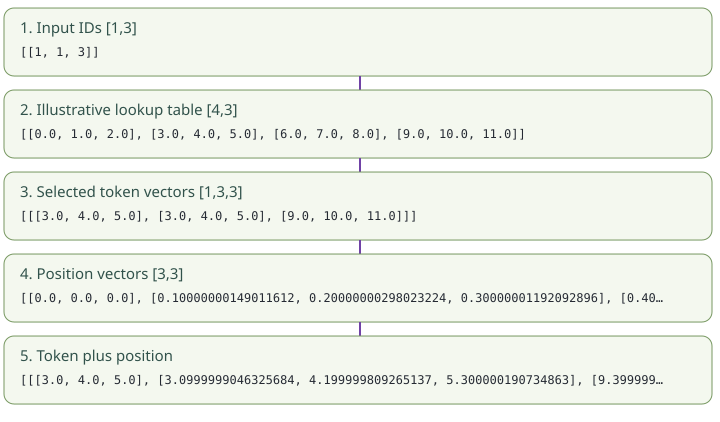

In [4]:
draw_trace()

### See the calculation

The plot uses the tensors just calculated above. Values are rounded for display.

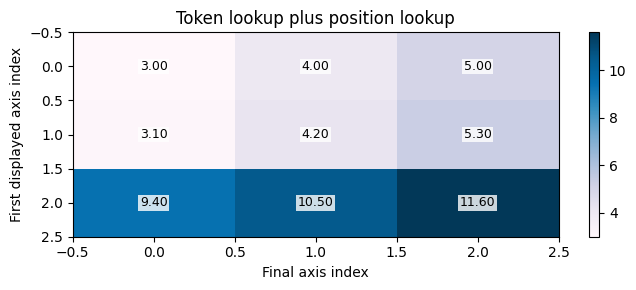

In [5]:
image = ((tokens+pos)[0]).detach().cpu().numpy()
fig, ax = plt.subplots(figsize=(7,3))
plot = ax.imshow(image, cmap="PuBu", aspect="auto")
for row in range(image.shape[0]):
    for col in range(image.shape[1]):
        ax.text(col,row,f"{image[row,col]:.2f}",ha="center",va="center",color="black",fontsize=9,
                bbox={"facecolor":"white","alpha":.8,"edgecolor":"none","pad":1})
ax.set_title('Token lookup plus position lookup'); ax.set_xlabel("Final axis index"); ax.set_ylabel("First displayed axis index")
fig.colorbar(plot,ax=ax); plt.tight_layout(); plt.show()

### Read the implementation

Construct Embedding with a vocabulary size and a feature width. Its weight parameter stores one feature vector per permitted ID.

The no-grad block sets hand-sized example weights without recording these assignments for differentiation. These are illustrative values, not a trained checkpoint.

Pass an integer ID tensor into the table. The output shape is the input shape followed by the embedding width.

Arange creates position IDs for the available time positions. The resulting time-by-feature tensor broadcasts across the batch when added to token vectors.

Check ID bounds and the maximum position index. Neither a larger vocabulary table nor a larger position table is created automatically when an index exceeds its size.

### Change one thing

**Change the second ID from 1 to 2**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [6]:
FRAMES.clear()
change = 1
torch.manual_seed(7)
table = nn.Embedding(4, 3)
positions = nn.Embedding(3, 3)
with torch.no_grad():
    table.weight.copy_(torch.arange(12).reshape(4,3).float())
    positions.weight.copy_(torch.tensor([[0.,0.,0.],[.1,.2,.3],[.4,.5,.6]]))
ids = torch.tensor([[1, 2 if change else 1, 3]])
show("Input IDs [1,3]", ids)
show("Illustrative lookup table [4,3]", table.weight)
tokens = table(ids)
show("Selected token vectors [1,3,3]", tokens)
pos = positions(torch.arange(ids.size(1)))
show("Position vectors [3,3]", pos)
show("Token plus position", tokens + pos)

Input IDs [1,3]: [[1, 2, 3]]
  shape [1, 3] · torch.int64 · cpu
Illustrative lookup table [4,3]: [[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0], [9.0, 10.0, 11.0]]
  shape [4, 3] · torch.float32 · cpu
Selected token vectors [1,3,3]: [[[3.0, 4.0, 5.0], [6.0, 7.0, 8.0], [9.0, 10.0, 11.0]]]
  shape [1, 3, 3] · torch.float32 · cpu
Position vectors [3,3]: [[0.0, 0.0, 0.0], [0.10000000149011612, 0.20000000298023224, 0.30000001192092896], [0.4000000059604645, 0.5, 0.6000000238418579]]
  shape [3, 3] · torch.float32 · cpu
Token plus position: [[[3.0, 4.0, 5.0], [6.099999904632568, 7.199999809265137, 8.300000190734863], [9.399999618530273, 10.5, 11.600000381469727]]]
  shape [1, 3, 3] · torch.float32 · cpu


### A useful distinction

Position vectors in this model are learned table entries. Token IDs are not multiplied into vectors as magnitudes.

### ✋ Your turn

Select IDs [2,0] from a table torch.arange(6).reshape(3,2) and put the nested result in answer.

In [7]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == [[4,5],[0,1]], 'Position vectors in this model are learned table entries. Token IDs are not multiplied into vectors as magnitudes.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [8]:
#@title Show a solution { display-mode: "form" }
answer = torch.arange(6).reshape(3,2)[torch.tensor([2,0])].tolist()

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == [[4,5],[0,1]], 'Position vectors in this model are learned table entries. Token IDs are not multiplied into vectors as magnitudes.'
    print("✓ right:", answer)

✓ right: [[4, 5], [0, 1]]


### Reconnect to the transformer

Our current model has sixty-five token vectors, each with twenty-eight features, and a separate table for thirty-two positions. Both tables are learned.

These position vectors come from lookup, not a sine formula. The course's mathematics collection explains that calculation and compares positional approaches where appropriate.

The token table is also used in the final readout. Its two uses contribute gradients to the same learned parameter during training.

Phyll uses larger tables and special token IDs. An embedding padding option and an ignored loss target are separate mechanisms and should not be conflated.

Next, inspect how modules register these parameters and keep their state organized.

```python
self.tok_emb = nn.Embedding(cfg.vocab_size, cfg.d_model)
self.pos_emb = nn.Embedding(cfg.block_size, cfg.d_model)
x = self.tok_emb(idx) + self.pos_emb(torch.arange(T, device=idx.device))
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** Does repeating an ID select the same token vector before position addition?

<details><summary>Check your explanation</summary>

Yes. Position vectors in this model are learned table entries. Token IDs are not multiplied into vectors as magnitudes.

</details>